In [15]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb
import preliz as pz

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='pytensor')

SEED = 12

## Parte 1: Modelos Lineales Generalizados (GLMs)


### 1.
Para el Dataset elegido, elegir variables para aplicar un modelo GLM Bayesiano
(pueden considerar una variable independiente y una variable respuesta, o trabajar
con mas de una para cada categorıa) y presentar un brvee resumen de cada una y
la relaci ́on entre variables (si ya lo hicieron en la Parte 0, no es necesario repetirlo).

In [39]:
pizza = pd.read_csv('../data/pizza_sales.csv')

In [40]:
pizza['order_hour'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S').dt.hour
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

In [41]:
pizza_junio = pizza.query('order_date >= "2015-06-01" & order_date < "2015-07-01"')

In [ ]:
conteo = pizza_junio.groupby(['order_date', 'order_hour']).size().reset_index(name='sales')

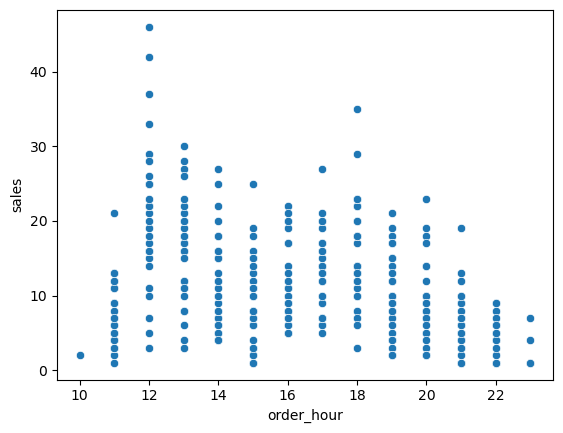

In [20]:
sns.scatterplot(data=conteo, x='order_hour', y='sales');

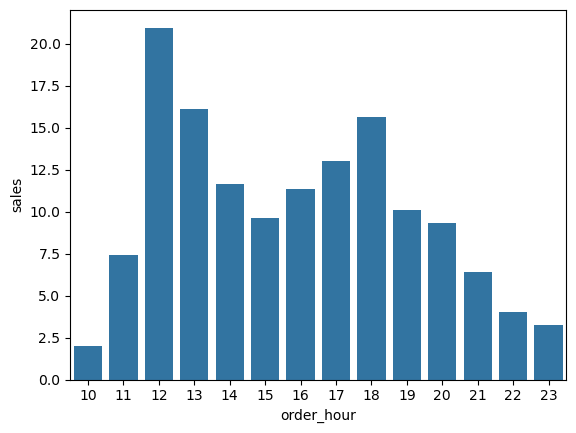

In [23]:
sns.barplot(data=conteo, x='order_hour', y='sales', errorbar=None);

Hay dos picos, no se puede capturar con una regresion lineal simple (grado 1)

### 2.
Seleccionar un modelo GLM adecuado al tipo de variable respuesta:  
• Continua: regresion lineal o con varianza variable.   
• Binaria: regresion logıstica.  
• Modelo con estructura jerarquica  
• (Opcional) De conteo: regresion Poisson o negativa binomial.  

In [27]:
print(f'Media: {round(conteo.sales.mean(), 2)}, Varianza: {round(conteo.sales.var(), 2)}')

Media: 11.4, Varianza: 54.26


Como nuestros datos son de conteo, usamos una regresión con familia Negativa Binomial porque encontramos sobre-dispersión (varianza >>> media).

In [28]:
degrees = [2, 3, 4, 5, 6, 7]
modelos = []
idatas = []

for d in degrees:
    modelo = bmb.Model(f'sales ~ poly(order_hour, {d})', conteo, family='negativebinomial')
    idata = modelo.fit(random_seed=SEED, idata_kwargs=dict(log_likelihood = True))
    modelos.append(modelo)
    idatas.append(idata)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 2)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 152 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 3)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 112 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 4)]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 112 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 6)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 115 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 7)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 96 seconds.


c:\Users\nazar\anaconda3\envs\ei2\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


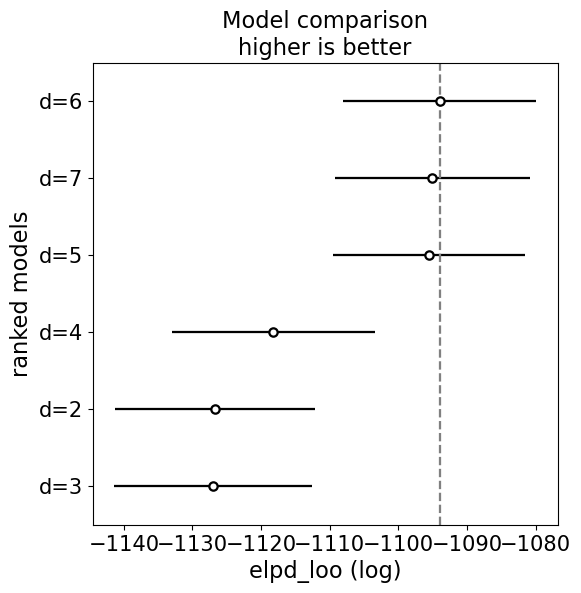

In [29]:
df_comp = az.compare({f'd={d}': idata for d, idata in zip(degrees, idatas)})
az.plot_compare(df_comp);

In [30]:
df_comp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
d=6,0,-1093.956537,9.649919,0.000000,7.123148e-01,14.084429,0.000000,True,log
d=7,1,-1095.041781,11.294390,1.085244,3.248399e-14,14.169995,1.117396,False,log
d=5,2,-1095.521209,7.328598,1.564672,2.749153e-01,13.979900,3.647468,False,log
d=4,3,-1118.235387,7.181343,24.278850,1.276984e-02,14.771046,7.691726,False,log
d=2,4,-1126.705720,4.011456,32.749183,2.943975e-14,14.552590,7.951498,False,log
d=3,5,-1127.019588,5.263583,33.063051,0.000000e+00,14.469409,7.683529,False,log


Grados 5, 6, y 7 tienen casi el mismo loo. Grado 6 fue el mejor pero tiene un warning. Grado 7 es mucho más comlpejo que grado 5.

Nos quedamos con grado 5 ya que ofrece buena capacidad predictiva sin complejizar demasiado el modelo.


### 3.
Formular las ecuaciones del modelo y justificar las distribuciones elegidas.

In [32]:
modelo = modelos[3]
idata = idatas[3]

In [33]:
modelo

       Formula: sales ~ poly(order_hour, 5)
        Family: negativebinomial
          Link: mu = log
  Observations: 353
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 2.5)
            poly(order_hour, 5) ~ Normal(mu: [0. 0. 0. 0. 0.], sigma: [46.9707 46.9707 46.9707 46.9707
                46.9707])
        
        
        Auxiliary parameters
            alpha ~ HalfCauchy(beta: 1.0)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()


### 4.
Interpretar los parametros de la distribucion posterior: medias, intervalos de credibilidad, relacion con los predictores.


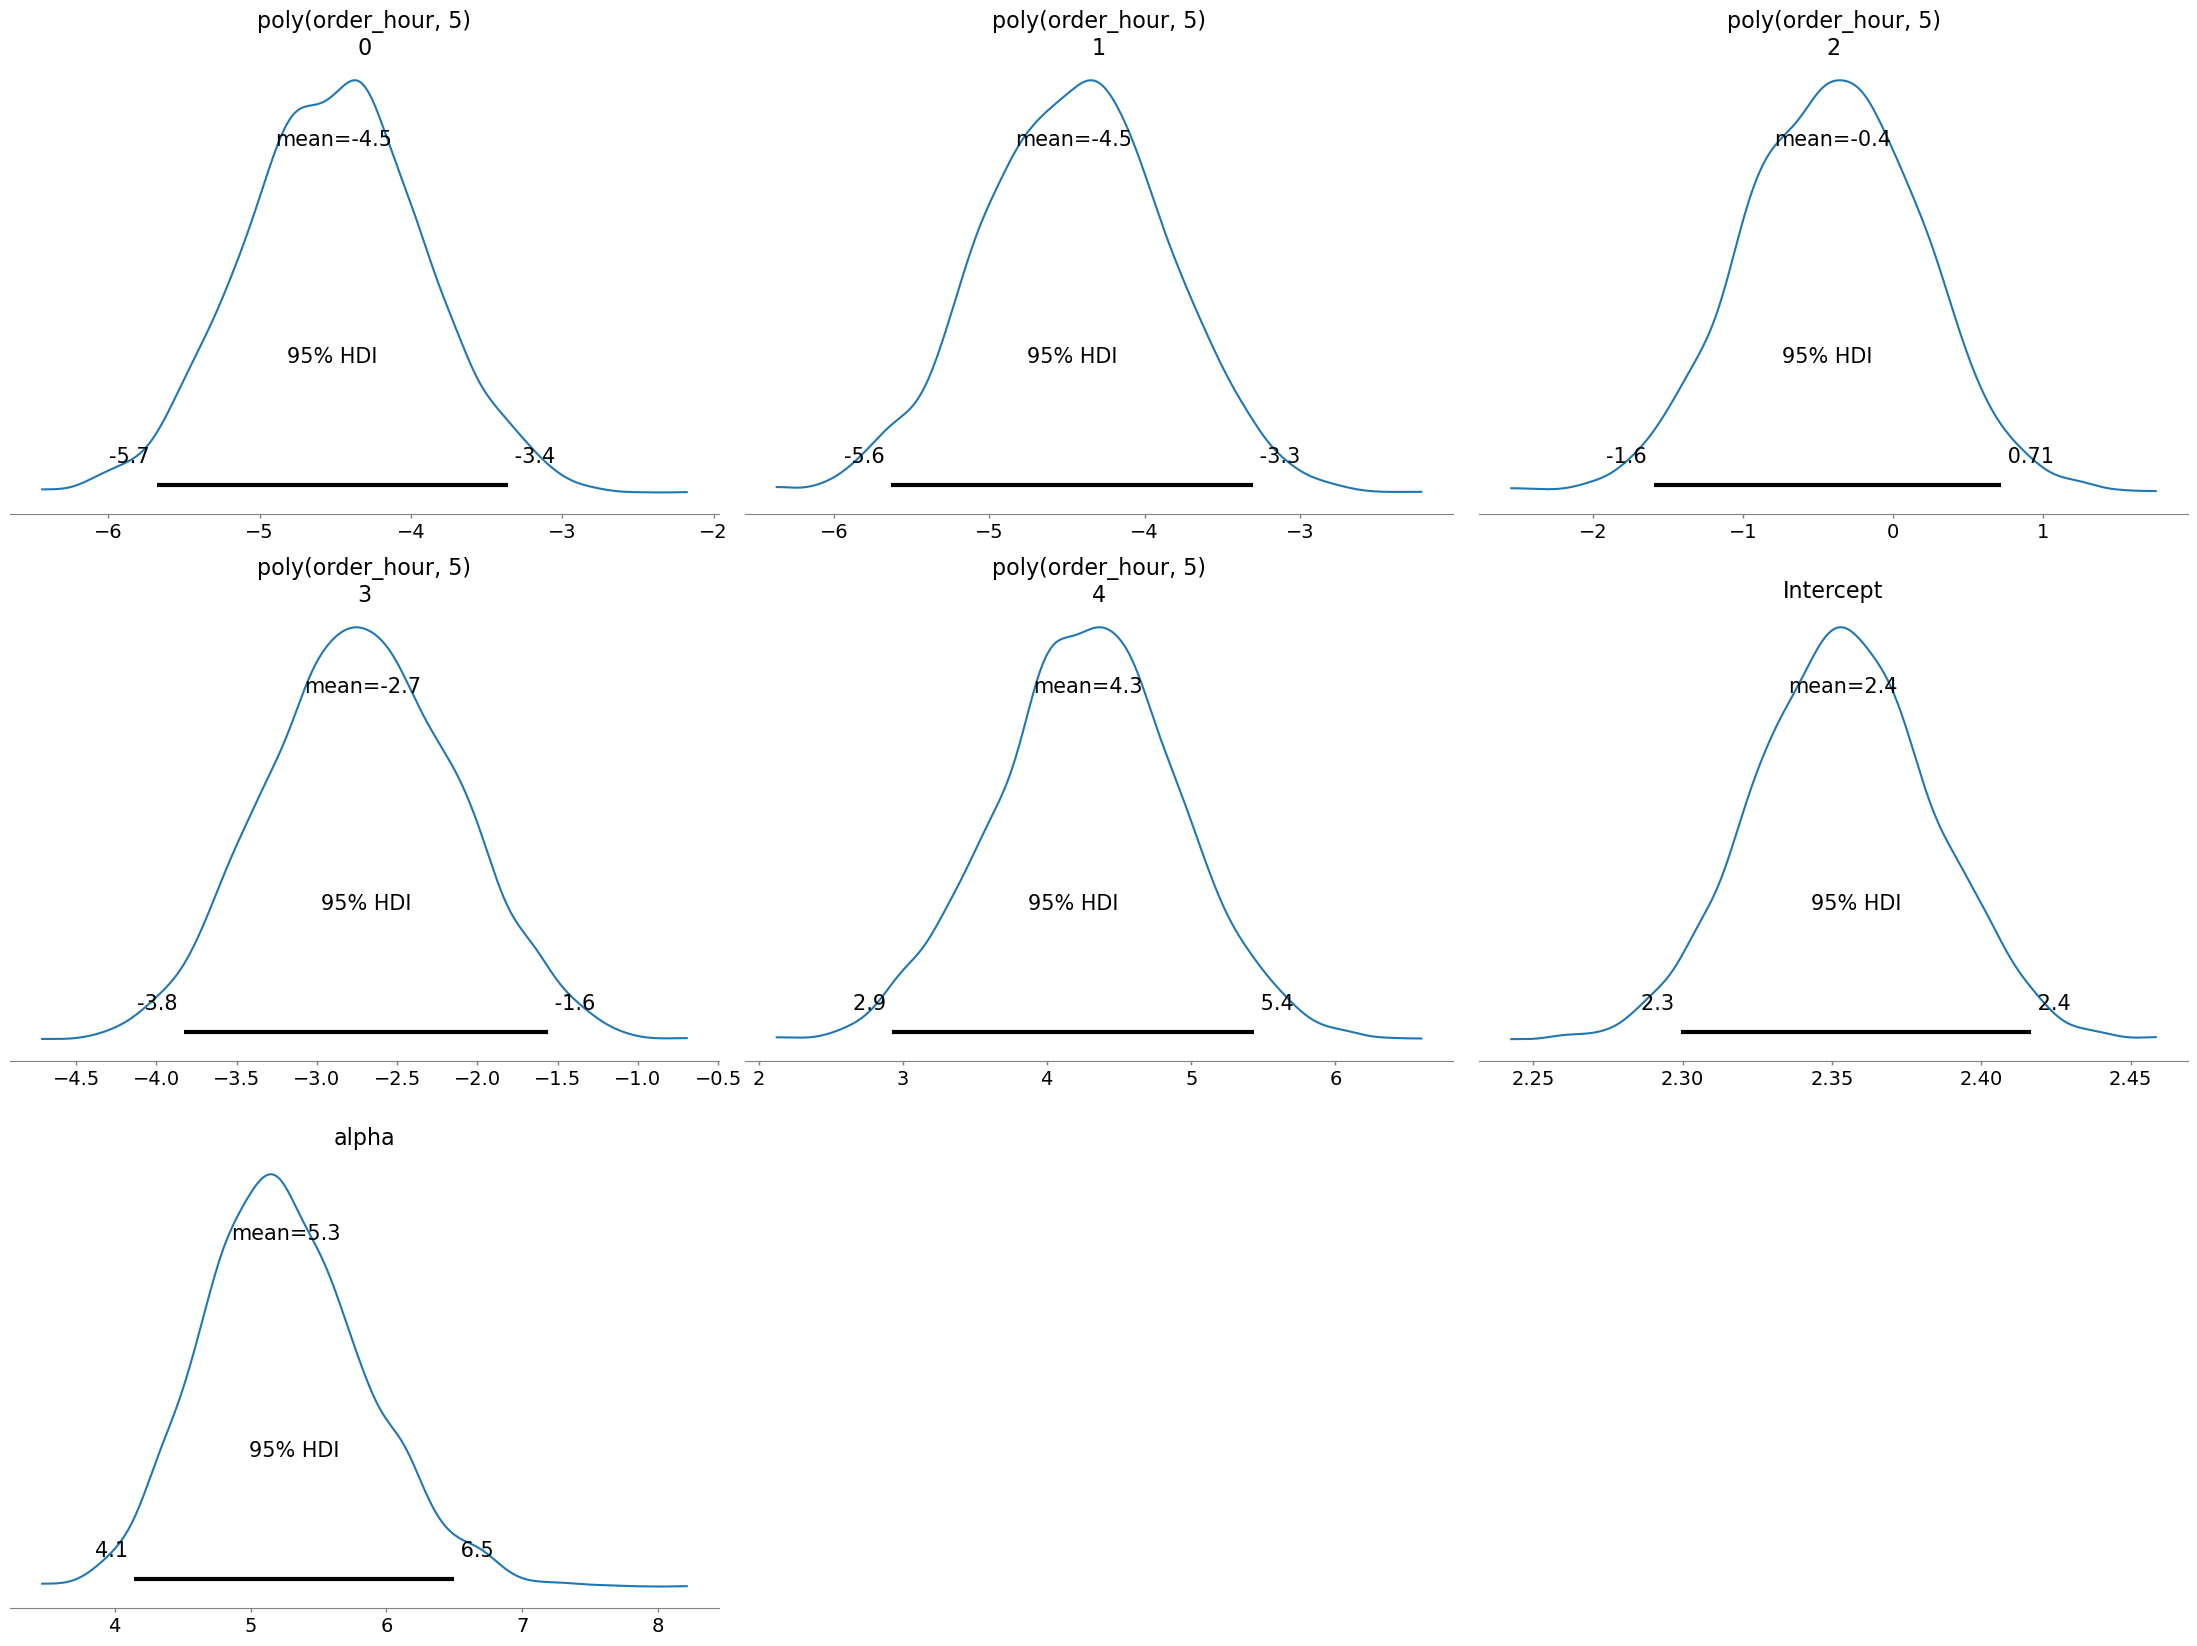

In [35]:
az.plot_posterior(idata, var_names=['poly(order_hour, 5)', 'Intercept', 'alpha'], hdi_prob=0.95)
plt.tight_layout();

El parámetro alpha tiene una media cercana a 3.9, lo que confirma la presencia de sobredispersión en los datos. El intercepto tiene una media de 2.4, que representa el nivel base de ventas en la escala del enlace logarítmico. Los coeficientes del polinomio de segundo grado (poly(order_hour, 2)) son negativos, lo que indica una relación curva: las ventas aumentan hasta cierto punto del día y luego disminuyen, reflejando los picos típicos de demanda en horarios de comidas.

Default computed for conditional variable: order_hour
Default computed for conditional variable: order_hour


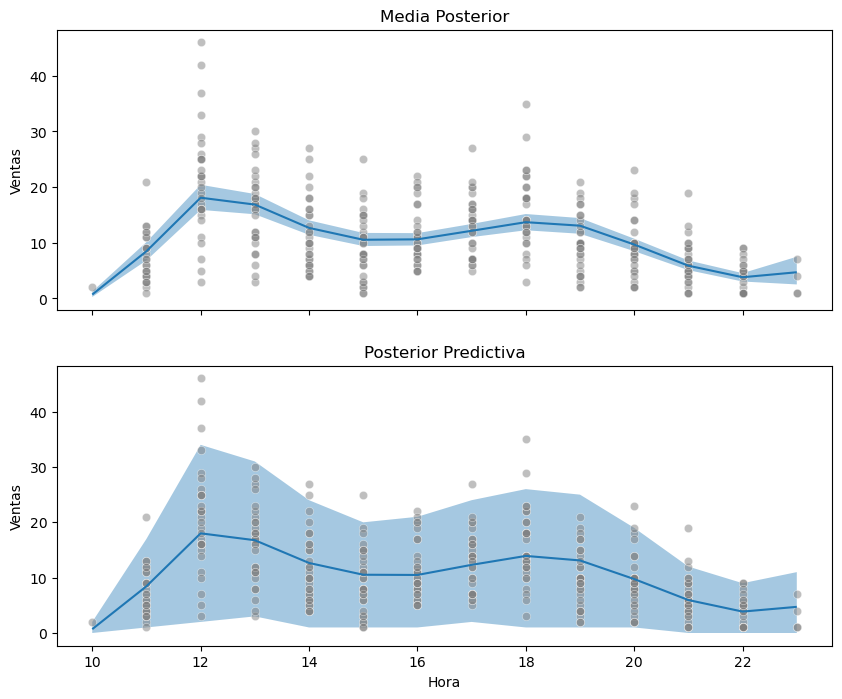

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

bmb.interpret.plot_predictions(modelo, idata, conditional=['order_hour'], ax=axes[0])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[0])
axes[0].set_title('Media Posterior')
axes[0].set_ylabel('Ventas')
axes[0].set_xlabel('')

bmb.interpret.plot_predictions(modelo, idata, conditional=['order_hour'], pps=True, ax=axes[1])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[1])
axes[1].set_title('Posterior Predictiva')
axes[1].set_ylabel('Ventas')
axes[1].set_xlabel('Hora');

El gráfico muestra cómo cambian las ventas de pizzas según la hora del día. Los puntos grises son los datos reales y la línea azul es la predicción del modelo con su zona de incertidumbre. Se ve que las ventas suben hacia el mediodía, alcanzan su punto máximo entre las 13 y 15 horas y después bajan gradualmente durante la tarde y la noche. Esto coincide con el patrón esperado: más pedidos en horarios de comida y menos en las horas más tarde del día.TAMBIEN


### 5.
Realizar predicciones a posteriori e interpretarlas en el contexto del problema.


Predecimos las ventas del próximo mes (Julio)

In [42]:
pizza_julio = pizza.query('order_date >= "2015-07-01" & order_date < "2015-08-01"')

In [ ]:
conteo_julio = pizza_julio.groupby(['order_date', 'order_hour']).size().reset_index(name='sales')

In [45]:
preds = modelo.predict(idata, data=conteo_julio, kind='response', inplace=False)

Default computed for conditional variable: order_hour


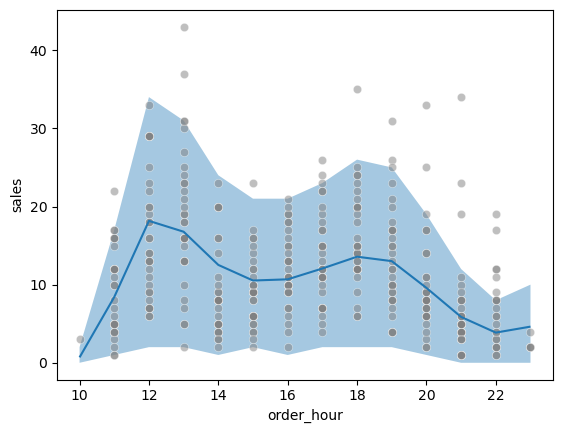

In [46]:
bmb.interpret.plot_predictions(modelo, preds, conditional=['order_hour'], pps=True)
sns.scatterplot(data=conteo_julio, x='order_hour', y='sales', alpha=0.5, color='grey');

El gráfico muestra que las ventas tienden a subir hacia el mediodía y después van bajando a lo largo de la tarde y la noche. La franja azul refleja la incertidumbre del modelo: donde es más ancha, el modelo está menos seguro de sus predicciones, algo lógico porque hay menos datos en esas horas.

Mencionar que varias de las horas por fuera del IC son del 4 de Julio (día de la independencia)

### 6.
Si el modelo lo permite, incluir predictores categoricos, interacciones o estructura jerarquica.

Suponemos que los días viernes y sábados se venden más pizzas y lo consideramos un grupo aparte.

In [ ]:
conteo['day_of_week'] = conteo['order_date'].dt.day_name()
conteo['grupo'] = conteo['day_of_week'].apply(lambda x: 'Saturday | Friday' if x in ['Saturday', 'Friday'] else 'Other')

In [80]:
modelo_cat = bmb.Model('sales ~ poly(order_hour, 5) + grupo', conteo, family='negativebinomial')

In [81]:
idata_cat = modelo_cat.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, poly(order_hour, 5), grupo]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 72 seconds.


In [84]:
modelo_cat.predict(idata_cat, kind='response', data=conteo)

Default computed for conditional variable: order_hour, grupo


Default computed for conditional variable: order_hour, grupo


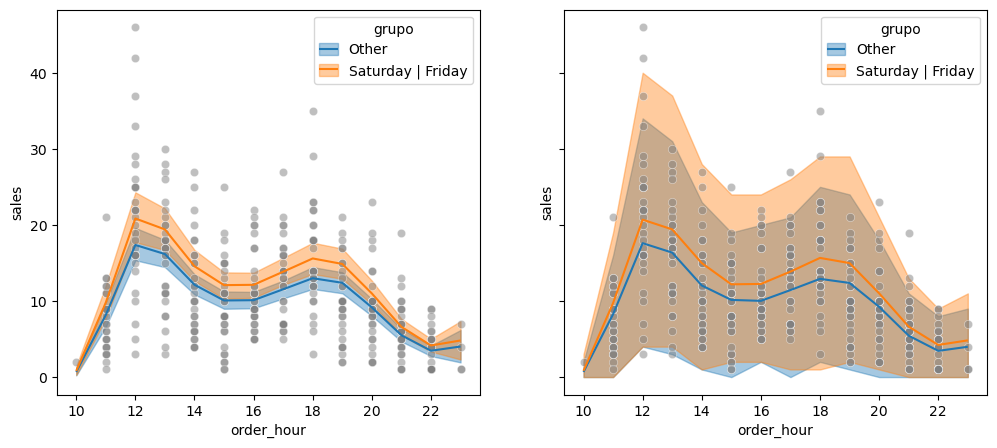

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bmb.interpret.plot_predictions(modelo_cat, idata_cat, conditional=['order_hour', 'grupo'], ax=axes[0])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[0]);
bmb.interpret.plot_predictions(modelo_cat, idata_cat, conditional=['order_hour', 'grupo'], pps=True, ax=axes[1])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[1]);

Lo que hace el modelo categorico es "mover" el intercepto. Mirar el modulo 5. https://lcd-unsam.github.io/estadistica_e_inferencia_II/05_GLMS.html#relaci%C3%B3n-con-modelos-jer%C3%A1rquicos 

El modelo muestra cómo varían las ventas según la hora del día y si es viernes o sábado. Se usó una regresión negativa binomial con un término cuadrático para capturar la forma curvada de la demanda. Los fines de semana tienen ventas claramente más altas, sobre todo entre las 13 h y 19 h, mientras que durante la semana el pico es menor y más temprano.

En ambos gráficos se ve el mismo patrón: la demanda sube hacia el mediodía y cae hacia la noche, pero el descenso es más lento los fines de semana.

### Extra: Splines

In [69]:
num_knots = 6
knots = np.linspace(10, 23, num_knots+2)[1:-1]

In [70]:
modelo_spline = bmb.Model('sales ~ bs(order_hour, knots=knots, degree=3)', conteo, family='negativebinomial')
idata_spline = modelo_spline.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, bs(order_hour, knots=knots, degree=3)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 85 seconds.


In [73]:
modelo_spline.predict(idata_spline, kind='response', data=conteo)

Default computed for conditional variable: order_hour
Default computed for conditional variable: order_hour


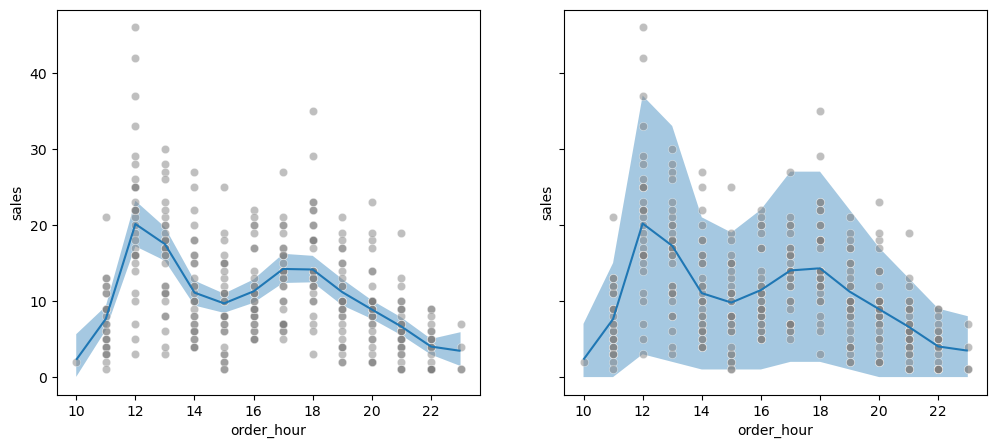

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bmb.interpret.plot_predictions(modelo_spline, idata_spline, conditional=['order_hour'], ax=axes[0])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[0]);
bmb.interpret.plot_predictions(modelo_spline, idata_spline, conditional=['order_hour'], pps=True, ax=axes[1])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[1]);

In [76]:
modelo_spline_cat = bmb.Model('sales ~ bs(order_hour, knots=knots, degree=3) + saturday_friday', conteo, family='negativebinomial')
idata_spline_cat = modelo_spline_cat.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, Intercept, bs(order_hour, knots=knots, degree=3), saturday_friday]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 91 seconds.


Para darle más flexibilidad al modelo usamos splines, que permiten que la curva se adapte mejor a los cambios reales en las ventas según la hora, sin forzar una forma fija como una parábola.

El resultado se ve más consistente, con un pico fuerte al mediodía, una baja después y un pequeño repunte a la tarde. El modelo ahora sigue el ritmo del día de forma más fluida y realista.

In [77]:
modelo_spline_cat.predict(idata_spline_cat, kind='response', data=conteo)

Default computed for conditional variable: order_hour, saturday_friday
Default computed for conditional variable: order_hour, saturday_friday


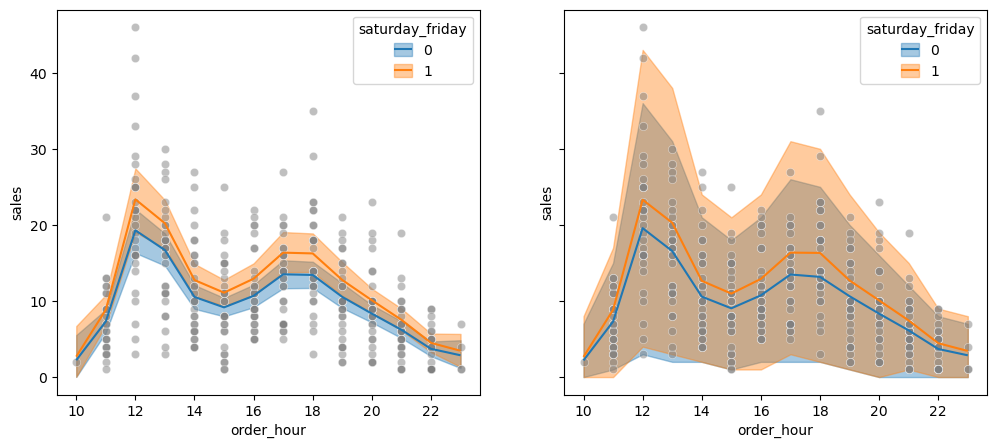

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bmb.interpret.plot_predictions(modelo_spline_cat, idata_spline_cat, conditional=['order_hour', 'saturday_friday'], ax=axes[0])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[0]);
bmb.interpret.plot_predictions(modelo_spline_cat, idata_spline_cat, conditional=['order_hour', 'saturday_friday'], pps=True, ax=axes[1])
sns.scatterplot(data=conteo, x='order_hour', y='sales', alpha=0.5, color='grey', ax=axes[1]);

Se observo que los viernes y sábados tienen más ventas en casi todas las horas del día, especialmente alrededor del mediodía y la tarde. Las bandas de incertidumbre son más amplias en esos días, lo que indica mayor variabilidad en la demanda. En cambio, los demás días  presentan menos ventas y un patrón más estable.